# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../Data/customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [4]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [5]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [6]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [7]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

In [8]:
df["booking_complete"].value_counts()

booking_complete
0    42522
1     7478
Name: count, dtype: int64

In [9]:
df.select_dtypes(include="object").nunique()

sales_channel       2
trip_type           3
route             799
booking_origin    104
dtype: int64

### Sales Channel Distribution

We first examine how customers make their bookings. Understanding the
distribution of sales channels helps identify whether one channel dominates
the dataset and whether booking behaviour differs by channel.

In [10]:
df["sales_channel"].value_counts()

sales_channel
Internet    44382
Mobile       5618
Name: count, dtype: int64

### Sales Channel vs Booking Completion

The distribution above shows that Internet is the dominant sales channel.
However, frequency alone does not tell us whether sales channel is predictive.

We therefore compare the average booking completion rate across sales channels.
Since `booking_complete` is binary (0/1), its mean represents the proportion
of customers who completed a booking.

In [11]:
df.groupby("sales_channel")["booking_complete"].mean()

sales_channel
Internet    0.154770
Mobile      0.108402
Name: booking_complete, dtype: float64

### Interpretation

Internet bookings have a completion rate of approximately 15.48%, compared
with 10.84% for Mobile bookings.

This suggests that sales channel may contain useful predictive information:
customers booking through the Internet are more likely to complete their
booking than customers using the Mobile channel.

However, this is an observed association, not evidence that the sales channel
causes customers to book.

### Trip Type Distribution

Next, we examine the types of trips customers are booking. Trip type may
capture differences in customer travel behaviour and may therefore help
explain booking completion.

In [12]:
df["trip_type"].value_counts()

trip_type
RoundTrip     49497
OneWay          387
CircleTrip      116
Name: count, dtype: int64

### Interpretation

The dataset is highly dominated by Round Trip bookings, with 49,497
observations. One Way bookings account for 387 observations, while Circle
Trip bookings account for only 116.

This means `trip_type` is highly imbalanced. Round Trip is the dominant
customer behaviour, while the other two categories have very few observations.
Therefore, differences in booking completion for One Way and Circle Trip
should be interpreted cautiously because their sample sizes are small.

### Trip Type vs Booking Completion

The distribution shows that Round Trip dominates the dataset. We now compare
booking completion rates across trip types to determine whether trip type
contains useful information for predicting booking completion.

In [13]:
df.groupby("trip_type")["booking_complete"].mean()

trip_type
CircleTrip    0.043103
OneWay        0.051680
RoundTrip     0.150575
Name: booking_complete, dtype: float64

### Interpretation

Round Trip customers have a booking completion rate of approximately 15.06%,
while One Way and Circle Trip customers have much lower rates of approximately
5.17% and 4.31%, respectively.

This suggests that `trip_type` may contain useful predictive information.
However, One Way and Circle Trip have very few observations, so their rates
should be interpreted cautiously and may be less reliable than the Round Trip
estimate.

### Numerical Feature Summary

We now examine the numerical variables to understand their typical values,
ranges, and distributions. This helps identify unusual values and gives us
an initial understanding of customer booking and travel behaviour.

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
num_passengers,50000.0,1.591240,1.020165,1.00,1.00,1.00,2.00,9.0
purchase_lead,50000.0,84.940480,90.451378,0.00,21.00,51.00,115.00,867.0
length_of_stay,50000.0,23.044560,33.887670,0.00,5.00,17.00,28.00,778.0
flight_hour,50000.0,9.066340,5.412660,0.00,5.00,9.00,13.00,23.0
flight_day,50000.0,3.814420,1.992792,1.00,2.00,4.00,5.00,7.0
wants_extra_baggage,50000.0,0.668780,0.470657,0.00,0.00,1.00,1.00,1.0
wants_preferred_seat,50000.0,0.296960,0.456923,0.00,0.00,0.00,1.00,1.0
wants_in_flight_meals,50000.0,0.427140,0.494668,0.00,0.00,0.00,1.00,1.0
flight_duration,50000.0,7.277561,1.496863,4.67,5.62,7.57,8.83,9.5
booking_complete,50000.0,0.149560,0.356643,0.00,0.00,0.00,0.00,1.0


### Interpretation

The numerical summary shows substantial variation in variables such as
`purchase_lead` and `length_of_stay`, with their maximum values considerably
higher than their median values. This suggests the presence of extreme
observations and potentially skewed distributions.

`num_passengers` is concentrated around small group sizes, with a median of
one passenger.

The preference variables are binary indicators, so their means represent the
approximate proportion of customers requesting each option.

The target variable `booking_complete` has a mean of approximately 0.15,
confirming that completed bookings represent only a minority of observations.

### Purchase Lead Distribution

We examine the distribution of `purchase_lead` to understand how far in
advance customers typically make their bookings and whether extreme values
are present.

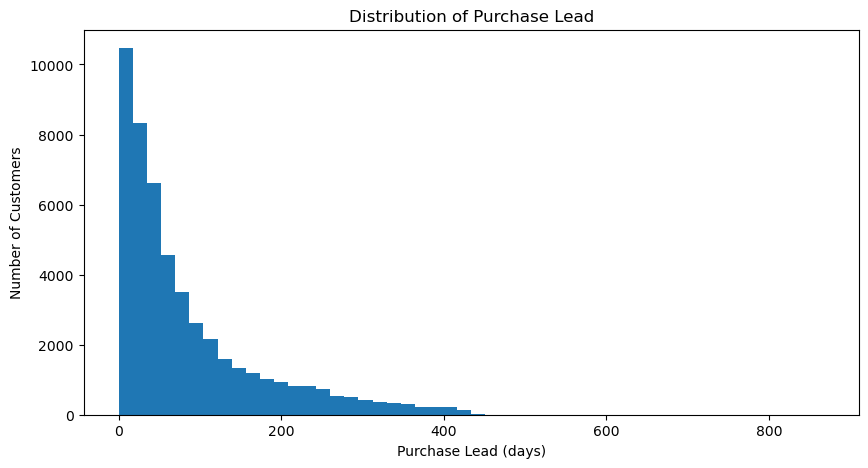

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df["purchase_lead"], bins=50)
plt.xlabel("Purchase Lead (days)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Purchase Lead")
plt.show()

### Interpretation

`purchase_lead` is strongly right-skewed. Most customers make their bookings
relatively close to the travel date, while a smaller number book substantially
further in advance.

The distribution has a long right tail containing relatively few observations,
including extreme values above 800 days. These observations should be
investigated rather than automatically removed, as they may still contain
useful predictive information.

### Length of Stay Distribution

We examine `length_of_stay` to understand the typical duration of customer
trips and identify whether extreme stay durations are present.

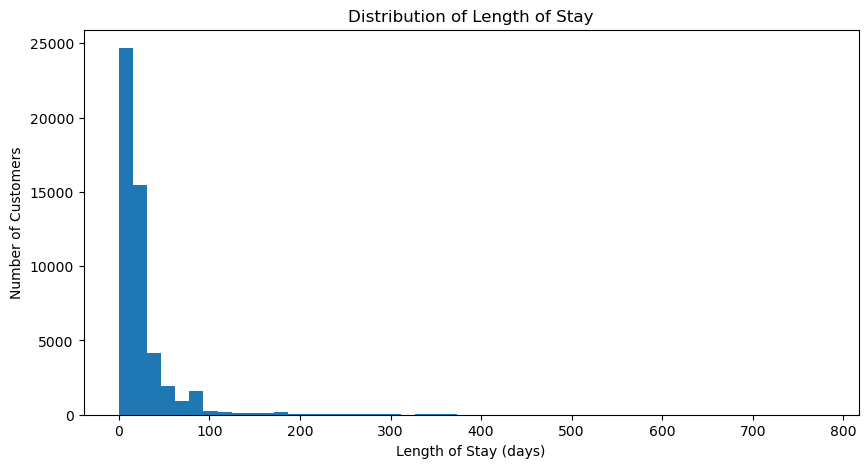

In [16]:
plt.figure(figsize=(10, 5))
plt.hist(df["length_of_stay"], bins=50)
plt.xlabel("Length of Stay (days)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Length of Stay")
plt.show()

### Interpretation

`length_of_stay` is strongly right-skewed. Most customers have relatively
short stays, while a small number of observations have substantially longer
stays.

The distribution contains a long right tail with extreme values extending to
several hundred days. These observations should be investigated rather than
automatically removed, as they may still contain predictive information.

### Flight Departure Time Distribution

We examine `flight_hour` to understand when flights are typically scheduled.
Departure time may capture differences in customer behaviour and booking
patterns.

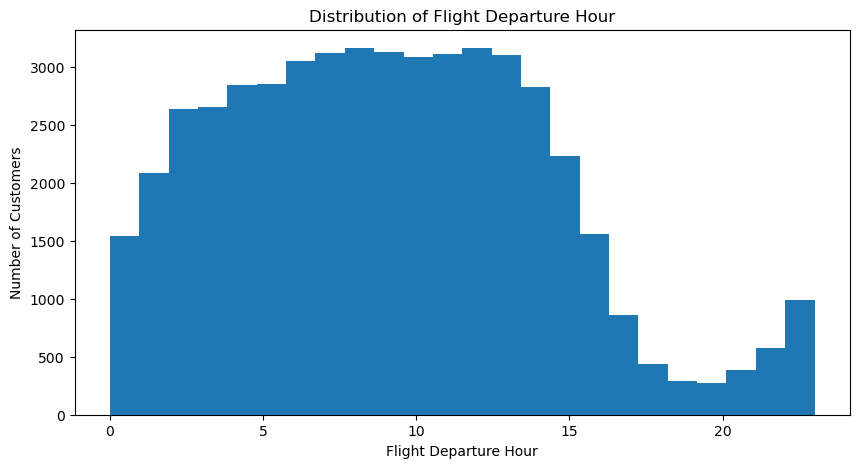

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(df["flight_hour"], bins=24)
plt.xlabel("Flight Departure Hour")
plt.ylabel("Number of Customers")
plt.title("Distribution of Flight Departure Hour")
plt.show()

### Interpretation

`flight_hour` is distributed across the full 24-hour range, with the highest
number of flights occurring during the daytime and early afternoon.

The distribution is not strongly skewed like `purchase_lead` or
`length_of_stay`. The variable also has a natural bounded range from 0 to 23,
representing the hour of departure.

### Flight Hour vs Booking Completion

We now compare booking completion rates across departure hours to investigate
whether the time of departure is associated with customer booking behaviour.

df.groupby("flight_hour")["booking_complete"].mean()

### Interpretation

Booking completion varies across departure hours. Completion rates are
relatively higher for flights around 14–18 hours and lower during the late
evening, particularly around 20–23 hours.

This suggests that `flight_hour` may contain useful predictive signal and
should be retained as a modelling feature.

## Feature Engineering

We now create a small number of features that represent meaningful
customer or travel behaviour.

The goal is not to create many variables unnecessarily, but to transform
existing information into features that may provide clearer predictive
signals to the model.

In [19]:
df["is_weekend"] = df["flight_day"].isin([6, 7]).astype(int)

In [20]:
df[["flight_day", "is_weekend"]].head()

,flight_day,is_weekend
0,6,1
1,6,1
2,3,0
3,6,1
4,3,0


## Preparing Data for Modelling

The target variable is `booking_complete`, which indicates whether the
customer completed a booking.

We separate the target from the predictor variables so that the model is
trained only on information that would be available for prediction.

In [21]:
X = df.drop("booking_complete", axis=1)
y = df["booking_complete"]

In [22]:
X.shape,y.shape

((50000, 14), (50000,))

## Train-Test Split

We split the dataset into training and testing sets before fitting the
preprocessing and machine-learning pipeline.

The training data is used to learn patterns, while the test data provides
an unseen sample for evaluating how well the final model generalises.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
X_train.shape, X_test.shape

((40000, 14), (10000, 14))

In [25]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(booking_complete
 0    0.85045
 1    0.14955
 Name: proportion, dtype: float64,
 booking_complete
 0    0.8504
 1    0.1496
 Name: proportion, dtype: float64)

### Interpretation

The training and testing sets have almost identical class distributions,
with approximately 85% non-completed bookings and 15% completed bookings.

Using `stratify=y` preserved the original target distribution in both datasets.
This is important because the target is imbalanced, and an unbalanced split
could make model evaluation less representative.

## Encoding Categorical Features

The dataset contains categorical variables that cannot be directly processed
by the machine-learning model.

We use one-hot encoding to represent these categories numerically without
introducing an artificial ranking between categories.

The encoding will be fitted as part of a preprocessing pipeline using the
training data, which helps prevent data leakage.

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = X.select_dtypes(include="object").columns
numerical_features = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

## Model Training — Random Forest

We use a Random Forest classifier because the task is a binary classification
problem and Random Forest can capture non-linear relationships and interactions
between features.

Combining preprocessing and the model in a single pipeline also ensures that
categorical encoding is applied consistently without fitting the encoder on
the test data.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

## Model Training

We now train the Random Forest using the training dataset.

The model will learn relationships between the customer/flight features and
the target variable `booking_complete`. The test dataset remains unseen
during training so that we can later evaluate how well the model generalises
to new customers.

In [28]:
# Train the complete preprocessing + Random Forest pipeline
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Model Prediction

The trained model is now used to predict booking completion for the unseen
test dataset.

Using unseen data allows us to evaluate whether the patterns learned during
training generalise to new customers.

In [29]:
y_pred = model.predict(X_test)

In [30]:
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [31]:
pd.Series(y_pred).value_counts()

0    9633
1     367
Name: count, dtype: int64

## Model Evaluation — Confusion Matrix

Because the target variable is imbalanced, we evaluate the model using a
confusion matrix rather than relying only on accuracy.

The confusion matrix shows how many observations were correctly and
incorrectly classified for each class, allowing us to assess how well the
model identifies customers who actually complete a booking.

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[8330,  174],
       [1303,  193]])

### Interpretation

The confusion matrix shows that the model correctly identifies most customers
who do not complete a booking (8,330 true negatives). However, it identifies
only 193 of the 1,496 customers who actually complete a booking, while missing
1,303 of them.

This indicates that the model is much better at predicting the majority class
than identifying completed bookings. Therefore, accuracy alone would not be
an appropriate measure of model performance for this imbalanced target.

In [33]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      8504
           1       0.53      0.13      0.21      1496

    accuracy                           0.85     10000
   macro avg       0.70      0.55      0.56     10000
weighted avg       0.81      0.85      0.81     10000



In [34]:
y_prob = model.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, y_prob)

0.7897442725914449

### Model Evaluation — Interpretation

The Random Forest achieves an accuracy of 85% and a ROC-AUC score of 0.790,
indicating useful predictive discrimination between customers who complete
and do not complete a booking.

However, performance on the minority class is considerably weaker. The recall
for completed bookings is only 0.13, meaning that the model identifies
approximately 13% of customers who actually complete a booking.

Precision for the booking class is 0.53, meaning that approximately 53% of
customers predicted as completing a booking actually do so.

The model therefore has useful predictive signal, but its default
classification threshold is conservative and results in many actual bookings
being missed. Accuracy alone would hide this limitation because the majority
class dominates the dataset.

## Feature Importance

Random Forest provides feature importance values that indicate how much each
processed feature contributes to the model's predictive decisions.

Because categorical variables were one-hot encoded, we first retrieve the
names of the transformed features so that the importance values can be
interpreted correctly.

In [35]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importances = model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
902,num__purchase_lead,0.153905
904,num__flight_hour,0.126110
903,num__length_of_stay,0.113254
905,num__flight_day,0.078197
901,num__num_passengers,0.047718
909,num__flight_duration,0.035598
849,cat__booking_origin_Malaysia,0.026273
908,num__wants_in_flight_meals,0.023196
803,cat__booking_origin_Australia,0.021880
906,num__wants_extra_baggage,0.017133


### Feature Importance — Interpretation

The Random Forest identifies `purchase_lead`, `flight_hour`, and
`length_of_stay` as the three most important individual features.

`purchase_lead` has the highest importance at approximately 15.4%, followed
by `flight_hour` at 12.6% and `length_of_stay` at 11.3%.

This indicates that booking timing and characteristics of the planned trip
provide substantial predictive information for the model.

Feature importance measures how much a feature contributes to the model's
predictions; it does not imply that the feature causes booking completion.

In [36]:
# Remove the preprocessing prefixes
feature_importance["original_feature"] = (
    feature_importance["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.split("_", n=1).str[0]
)

grouped_importance = (
    feature_importance
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

grouped_importance

original_feature
route       0.259191
flight      0.239905
purchase    0.153905
length      0.113254
booking     0.100213
wants       0.057213
num         0.047718
is          0.016140
sales       0.010777
trip        0.001684
Name: importance, dtype: float64

In [38]:
# Get transformed feature names and their importances
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["classifier"].feature_importances_

# Create a fresh dataframe
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Map each transformed feature back to its original column
def get_original_feature(feature):
    feature = feature.replace("num__", "").replace("cat__", "")
    
    for col in original_features:
        if feature == col or feature.startswith(col + "_"):
            return col

    return feature

feature_importance["original_feature"] = (
    feature_importance["feature"].apply(get_original_feature)
)

# Aggregate importance by original variable
grouped_importance = (
    feature_importance
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

grouped_importance

original_feature
route                    0.259191
purchase_lead            0.153905
flight_hour              0.126110
length_of_stay           0.113254
booking_origin           0.100213
flight_day               0.078197
num_passengers           0.047718
flight_duration          0.035598
wants_in_flight_meals    0.023196
wants_extra_baggage      0.017133
wants_preferred_seat     0.016883
is_weekend               0.016140
sales_channel            0.010777
trip_type                0.001684
Name: importance, dtype: float64

## Aggregated Feature Importance — Interpretation

The feature importance values were aggregated back to the original dataset
variables because categorical variables such as `route` and `booking_origin`
were expanded into multiple one-hot encoded features.

`route` is the most important variable in the Random Forest, accounting for
approximately 25.9% of total feature importance. It is followed by
`purchase_lead` (15.4%), `flight_hour` (12.6%), `length_of_stay` (11.3%),
and `booking_origin` (10.0%).

Together, these five variables account for approximately 74.3% of the
model's total feature importance. This suggests that route, booking timing,
departure time, trip duration, and booking origin provide substantial
predictive information for booking completion.

Feature importance describes a variable's contribution to the model's
predictions and should not be interpreted as evidence of causation.

## Feature Importance Visualization

We visualize the aggregated feature importance to clearly communicate which
original variables contribute most to the Random Forest's predictive power.
This provides an interpretable summary of the model for business
stakeholders.

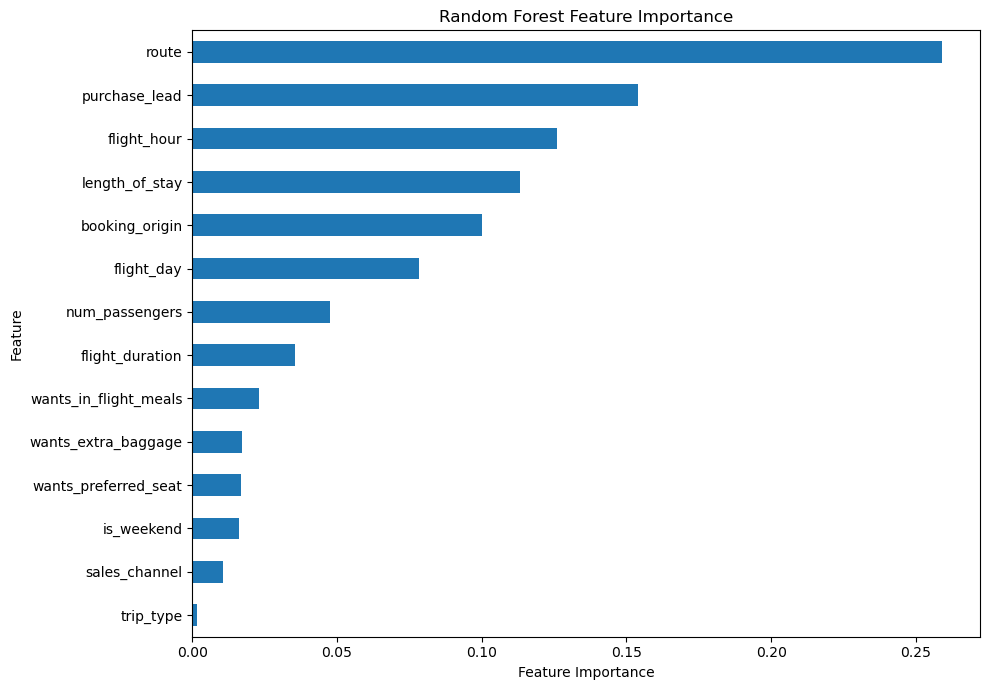

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

grouped_importance.sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

## Feature Importance — Business Interpretation

The feature importance visualization shows that `route` is the strongest
predictive variable, followed by `purchase_lead`, `flight_hour`,
`length_of_stay`, and `booking_origin`.

These results suggest that the customer's planned route, booking timing,
departure time, trip duration, and booking origin provide the strongest
predictive signals for booking completion in the Random Forest model.

The remaining variables contribute smaller amounts individually, while
`trip_type` provides very little predictive contribution.

Feature importance represents predictive contribution within the trained
model and should not be interpreted as causal impact.

## Cross-Validation

Cross-validation is used to assess whether the model's performance is
consistent across different subsets of the training data rather than
depending on a single train-test split.

Because the target is imbalanced, stratified cross-validation is used so that
each fold maintains a similar proportion of booking and non-booking cases.

In [40]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Cross-validation ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation ROC-AUC scores: [0.77858146 0.77225329 0.77200641 0.78178333 0.77774493]
Mean ROC-AUC: 0.7764738827897821
Standard deviation: 0.0037952450933613348


## Cross-Validation — Interpretation

The Random Forest achieved a mean ROC-AUC of approximately 0.776 across
5 stratified cross-validation folds, with a standard deviation of only 0.0038.

The low standard deviation indicates that model performance is consistent
across different subsets of the training data. The test-set ROC-AUC of
approximately 0.790 is also reasonably close to the cross-validation result,
suggesting that the model generalizes reasonably well to unseen data.

Overall, the model provides useful predictive discrimination, although there
is still substantial room for improvement before using it as a production
decision-making system.